<div style="display: flex; align-items: center; padding: 20px; background-color: #f0f2f6; border-radius: 10px; border: 2px solid #007bff;">
    <img src="../logo.png" style="width: 80px; height: auto; margin-right: 20px;">
    <div style="flex: 1; text-align: left;">
    <h1 style="color: #007bff; margin-bottom: 5px;">GLY 6739.017S26: Computational Seismology</h1>
    <h3 style="color: #666;">Notebook 130: RSAM example 2 - Redoubt volcano</h3>
    <p style="color: red;"><i>Glenn Thompson | Spring 2026</i></p>
    </div>
</div>

# RSAM example 2 - Redoubt volcano unrest/eruptions March 2009

These data come from vertical components of stations REF & RSO at Redoubt Volcano in Alaska from 2009/03/19 to 2009/03/23.

## 1. Import path to the Samba share
First, make sure you have mounted the Samba share from the server "hal9000". Do you remember how we did this in week 8?

Next, let's set the path to the Samba mounted share from the server 'hal9000', as we did in week8:

In [24]:
import sys
sys.path.append('../week8')
from set_samba_data_root import DATA_ROOT
print(DATA_ROOT)

/Volumes/classdata


## 2. Load data from the SDS archive

SDS_ROOT: /Volumes/classdata/SDS_Alaska
Date range: 2009-03-19T00:00:00.000000Z to 2009-03-23T07:00:00.000000Z
2 Trace(s) in Stream:
AV.REF..EHZ | 2009-03-19T00:00:00.000000Z - 2009-03-23T07:00:00.000000Z | 100.0 Hz, 37080001 samples (masked)
AV.RSO..EHZ | 2009-03-19T00:00:00.000000Z - 2009-03-23T07:00:00.000000Z | 100.0 Hz, 37080001 samples (masked)


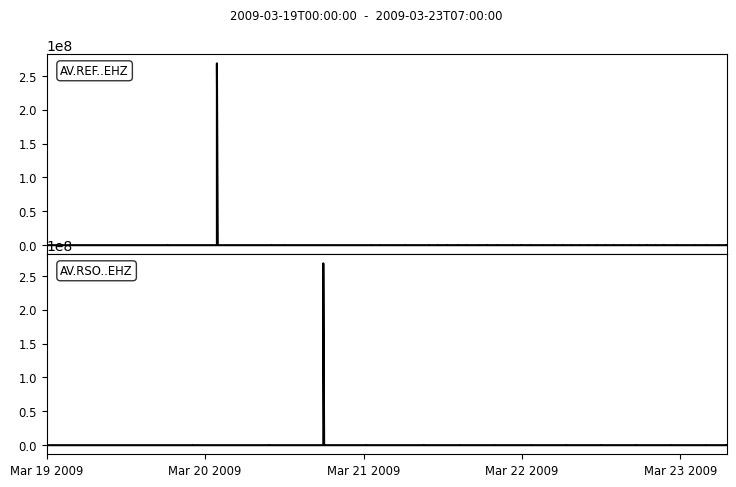

In [17]:
from flovopy.processing.sam import RSAM # RSAM class from flovopy
#from obspy.clients.filesystem.sds import Client # for reading SDS archives
from flovopy.enhanced.sdsclient import EnhancedSDSClient
from obspy.core import UTCDateTime, Stream

SDS_ROOT = DATA_ROOT / "SDS_Alaska"   # <-- SDS archive made from AVO and AEC data
NET = "AV"
STATIONS = ['REF', 'RSO'] # a list of stations
LOC = ""
CHA = "EHZ"   # vertical channels only

# Date range (inclusive start, exclusive end)
t0 = UTCDateTime("2009-03-19T00:00:00")
t1 = UTCDateTime("2009-03-23T07:00:00")

print(f"SDS_ROOT: {SDS_ROOT}")
print(f"Date range: {t0} to {t1}")

# Create SDS client
client = EnhancedSDSClient(str(SDS_ROOT))

st = Stream() # create an empty Stream object
for STA in STATIONS: # Loop over all stations (well just 2)
    temp_st = client.get_waveforms(NET, STA, LOC, CHA, t0, t1) # <-- Read data from SDS
    temp_st.merge() # otherwise we get lots of Trace objects for each SEED id
    for tr in temp_st: # Loop over each Trace in this temporary Stream
        st.append(tr) # Append this Trace to the master Stream
print(st)
st.plot(equal_scale=False);

You can't see much here because both traces have spikes. They are both peak at around 250,000,000 counts! Both RSO and REF are short-period seismometers with analog FM telemetry. That means the data are digitized at the observatory. So this is probably some digitizer noise from interference. 

## 3. What is analog FM telemetry?

In FM (frequency modulation) radio telemetry, a measured signal (like seismic amplitude) is used to vary the frequency of a high-frequency carrier wave, which is a stable radio signal (a sine wave, e.g. at 400 MHz) that can travel long distances. The original data signal itself is too low-frequency to transmit efficiently (and would require massive antennas), so it is encoded onto the carrier through modulation—in FM, this means small changes in frequency represent the signal’s variations. At the receiving end, a demodulator extracts (recovers) the original signal by tracking those frequency changes and converting them back into the measured data.

Antenna size is fundamentally tied to the wavelength of the signal, which is inversely proportional to frequency ($\lambda = c/f$). Efficient antennas are typically a fraction of the wavelength (often a quarter-wave), so higher-frequency radio signals use conveniently small antennas. For example, a 400 MHz signal has a wavelength of ~0.75 m, so a quarter-wave antenna is only ~19 cm long. In contrast, seismic signals are extremely low frequency (e.g., 1 Hz), corresponding to wavelengths of hundreds of thousands of kilometers—meaning a quarter-wave antenna would be tens of thousands of kilometers long. This is why seismic data cannot be transmitted directly at its native frequency and instead must be modulated onto a high-frequency carrier for practical radio telemetry.

### Here is a little demo of FM 

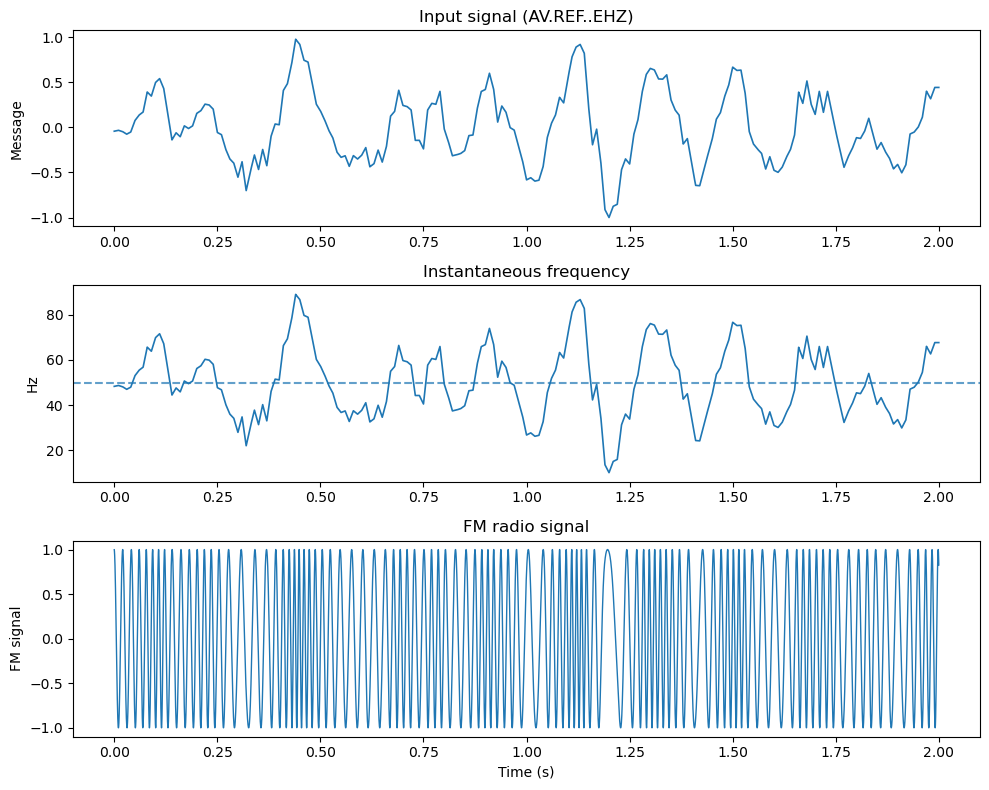

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from obspy import Trace

def plot_fm_like_wikipedia(
    tr: Trace,
    carrier_hz: float = 100.0,
    peak_deviation_hz: float = 20.0,
    duration: float = 2.0,
    sim_fs: float = 5000.0,
):
    """
    Plot a real FM waveform like the classic AM/FM modulation diagrams.

    Parameters
    ----------
    tr : obspy.Trace
        Input trace used as the message signal.
    carrier_hz : float
        Carrier frequency for the visible demo.
    peak_deviation_hz : float
        Peak frequency deviation when the normalized message reaches ±1.
    duration : float
        Seconds of input trace to use.
    sim_fs : float
        Internal sample rate for plotting the carrier waveform cleanly.
    """
    fs_in = float(tr.stats.sampling_rate)
    if fs_in <= 0:
        raise ValueError("Trace must have a positive sampling rate.")
    if sim_fs <= 10 * carrier_hz:
        raise ValueError("sim_fs should be much larger than carrier_hz for a clean plot.")

    # --- input message ---
    n_in = min(len(tr.data), int(duration * fs_in))
    x = tr.data[:n_in].astype(float)
    t_in = np.arange(n_in) / fs_in

    # normalize message to [-1, 1]
    x = x - np.mean(x)
    peak = np.max(np.abs(x))
    if not np.isfinite(peak) or peak == 0:
        raise ValueError("Trace has no usable amplitude variation.")
    m_in = x / peak

    # --- interpolate message to a fine grid for visible carrier plotting ---
    n_sim = int(duration * sim_fs)
    t = np.arange(n_sim) / sim_fs
    m = np.interp(t, t_in, m_in)

    # --- actual FM waveform ---
    # instantaneous frequency
    f_inst = carrier_hz + peak_deviation_hz * m

    # phase = integral of instantaneous frequency
    phase = 2 * np.pi * np.cumsum(f_inst) / sim_fs

    # real FM signal: constant amplitude, variable cycle spacing
    s_fm = np.cos(phase)

    # --- plots ---

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=False)

    axes[0].plot(t, m, linewidth=1.2)
    axes[0].set_ylabel("Message")
    axes[0].set_title(f"Input signal ({tr.id})")

    axes[1].plot(t, f_inst, linewidth=1.2)
    axes[1].axhline(carrier_hz, linestyle="--", alpha=0.7)
    axes[1].set_ylabel("Hz")
    axes[1].set_title("Instantaneous frequency")

    axes[2].plot(t, s_fm, linewidth=1.0)
    axes[2].set_ylabel("FM signal")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title(
        f"FM radio signal"
    )

    fig.tight_layout()
    plt.show()

    return {
        "t": t,
        "message": m,
        "f_inst": f_inst,
        "fm_signal": s_fm,
    }

duration = 2
tr = st[0].copy().trim(starttime=t0+2, endtime=t0 + 2 + duration)  # Use first 5 seconds of the first Trace
result = plot_fm_like_wikipedia(
    tr,
    carrier_hz=50.0,
    peak_deviation_hz=40.0,
    duration=duration,
    sim_fs=5000.0,
)



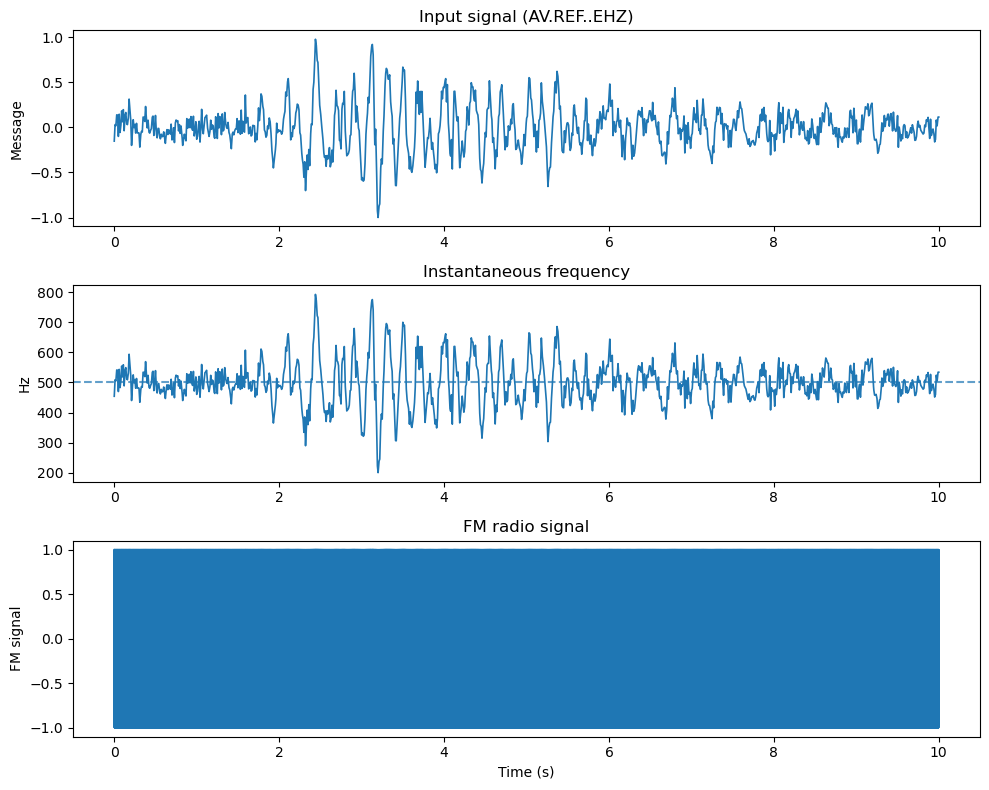

In [19]:
import numpy as np
from scipy.io.wavfile import write

def trace_to_wav(trace, filename, target_fs=44100):
    """
    Convert ObsPy Trace to WAV audio file.
    """

    tr = trace.copy()

    # Resample if needed
    if tr.stats.sampling_rate != target_fs:
        tr.resample(target_fs)

    data = tr.data.astype(np.float64)

    # Remove mean
    data = data - np.mean(data)

    # Normalize to [-1, 1]
    data /= np.max(np.abs(data))

    # Convert to 16-bit PCM
    audio = np.int16(data * 32767)

    write(filename, target_fs, audio)

duration = 10
tr = st[0].copy().trim(starttime=t0, endtime=t0 + duration)  # Use first 5 seconds of the first Trace
result = plot_fm_like_wikipedia(
    tr,
    carrier_hz=500.0,
    peak_deviation_hz=300.0,
    duration=duration,
    sim_fs=500000.0,
)

trace_to_wav(tr, "seismogram.wav")

The panels above show: (top) original analog signal, (middle) mapping from amplitude to frequency. The carrier wave here has a frequency of 50 Hz, and can vary by up to 30 Hz (20 Hz - 80 Hz) to cover the range from the most -ve to the most +ve amplitude in the signal. (bottom) the frequency modulated radio signal. This looks like a spring, where compressions (up to 80 Hz) indicate high amplitudes, and rarefactions (down to 20 Hz) indicate low amplitudes. I reality the carrier wave would be more like 400 MHz, but we wouldn't be able to see that vary on a plot, so we used just 50 Hz.

A demodulator at the observatory reverses (decodes) the encoding, and recovers the original signal. In reality, each seismic station in FM telemetry operates in a different FM band to avoid interference, and discriminators (tuned radios essentially) are used to "listen" to each incoming signal, and send it to a demodulator.


## 4. Despiking seismic data

OK, so following that aside on FM radio, let's get back to our problem - SPIKES!

How can we eliminate high amplitude spikes? Numpy has a clip() function. Let's try that. But what is the actual range of good data? We could just clip at say twice the 99% percentile. Let's try that!

/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


Clipping AV.REF..EHZ at 12234.00
Clipping AV.RSO..EHZ at 4086.00


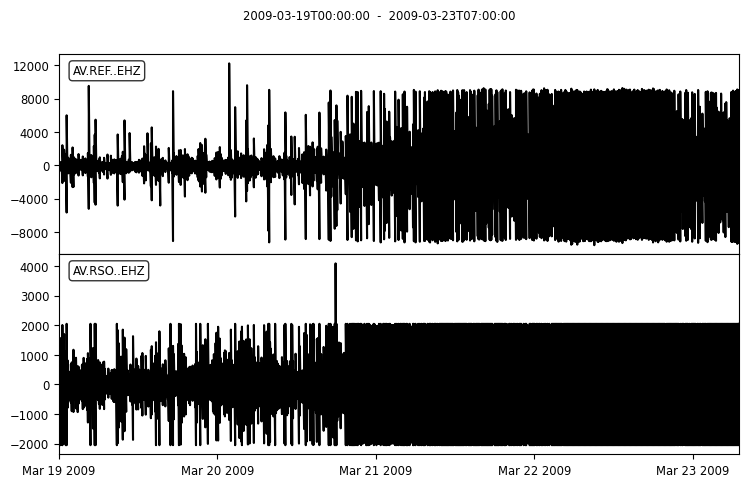

In [20]:
import numpy as np

def clip_trace(trace, percentile=99.9):
    '''
    Clip the data in this Trace to +/- 2x the given percentile of the absolute value of the data.
    '''
    x = trace.data
    clip_level = np.nanpercentile(np.abs(x), percentile) * 2
    print(f"Clipping {trace.id} at {clip_level:.2f}")
    trace.data = np.clip(trace.data, -clip_level, clip_level)

def clip_stream(stream, percentile=99.9):
    for tr in stream:
        clip_trace(tr, percentile=percentile)

st2 = st.copy()
clip_stream(st2, percentile=99.9)
st2.plot(equal_scale=False);

So now we can see the range of the REAL signal. Notice that data are still squared off. Why? That is likely because the analog FM telemetry itself had limited dynamic range. FM, or Frequency Modulated, radio signals are broadcast in a certain radio frequency band. So they have a minimum and maximum frequency, which correspond to a minimum and maximum amplitude. So the FM telemetry likely clipped the signal coming from the short-period seismometer, squaring off the tops and bottoms of the signal.

It looks like we have continuous square waves on RSO from late on March 20, 2009. Let's zoom in to see if that is true:

/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


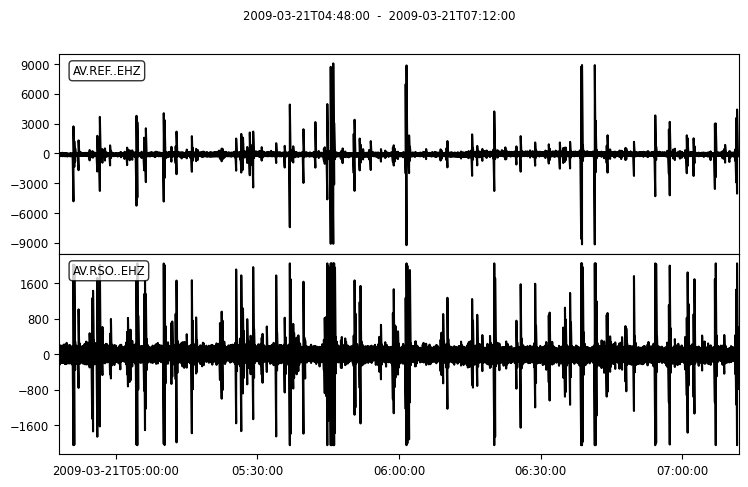

In [21]:
st2.plot(equal_scale=False, starttime=t0+86400*2.2, endtime=t0+86400*2.3);

So by zooming in we can see there is actually plenty of usable signal.

So let's now compute some RSAM data!

Let's see what helpful information we can get about the RSAM class:

In [22]:
help(RSAM)

Help on class RSAM in module flovopy.processing.sam:

class RSAM(SAM)
 |  RSAM(dataframes=None, stream=None, sampling_interval: float = 60.0, filter=[0.5, 18.0], bands={'VLP': [0.02, 0.2], 'LP': [0.5, 4.0], 'VT': [4.0, 18.0]}, corners: int = 4, despike: bool = False, verbose: bool = False)
 |
 |  Method resolution order:
 |      RSAM
 |      SAM
 |      builtins.object
 |
 |  Class methods defined here:
 |
 |  readRSAMbinary(SAM_DIR=None, station=None, stime=None, etime=None, filepath=None, sampling_interval=60, verbose=False, convert_legacy_ids_using_this_network=None, fill_missing_with=0.0)
 |      Read RSAM binary file(s) and return an RSAM object.
 |
 |      Either:
 |      - provide `filepath`, `stime`, and `etime` to read a single file, or
 |      - provide `SAM_DIR`, `station`, `stime`, and `etime` to read from structured archive.
 |
 |      `station` may be a string or list.
 |
 |      Parameters
 |      ----------
 |      fill_missing_with : float or None
 |          Value use

## 5. Compute RSAM data

RSAM object:
Number of SEED ids: 2 [['AV.REF..EHZ', 'AV.RSO..EHZ']]
Number of rows: 6180
Start time: 2009-03-19T00:00:00.000000Z
End time: 2009-03-23T07:00:00.000000Z
Duration: 370800.0 s
Sampling interval: 60.0 s
Metrics: min, mean, max, median, rms, VLP, LP, VT, fratio
AV.REF..EHZ: median=36.5
AV.RSO..EHZ: median=48.7
METRIC: mean
Regularizing dataframe with 6180 rows onto a 60 s grid based on column 'time'
Regularizing dataframe with 6180 rows onto a 60 s grid based on column 'time'


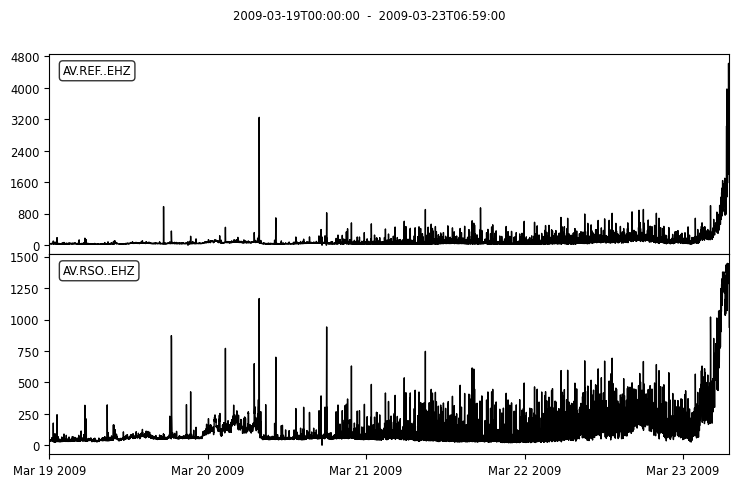

In [23]:
rsamObj = RSAM(stream=st2, sampling_interval=60) # 60-s sampling interval
print(rsamObj)
rsamObj.plot()